hankel matrix: (8, 5000)


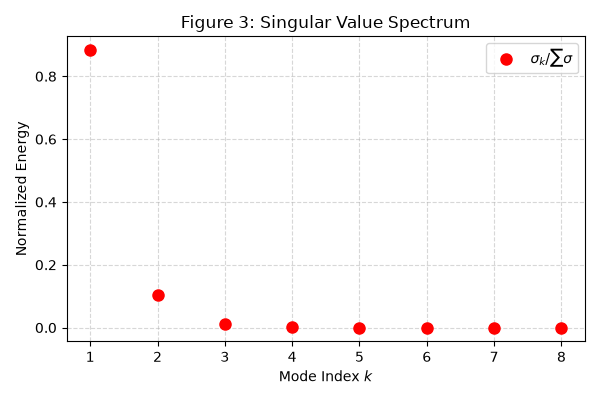

Shape of U matrix: (8, 8)
 Shape of s matrix: (8,) 
 Shape of V matrix: (8, 5000)


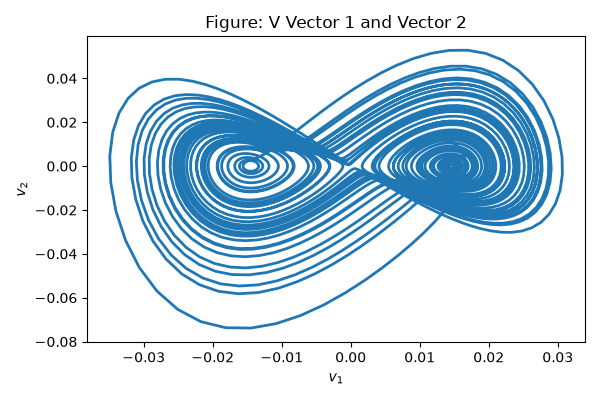

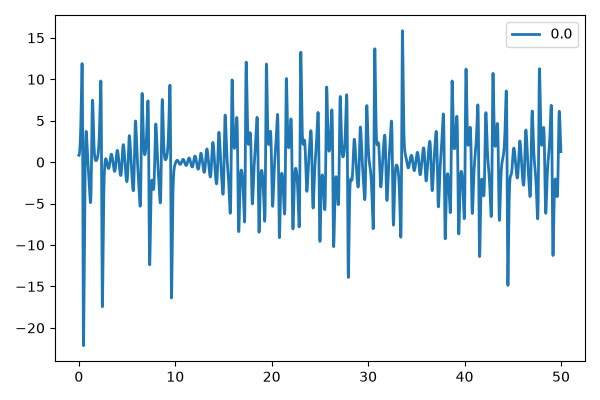

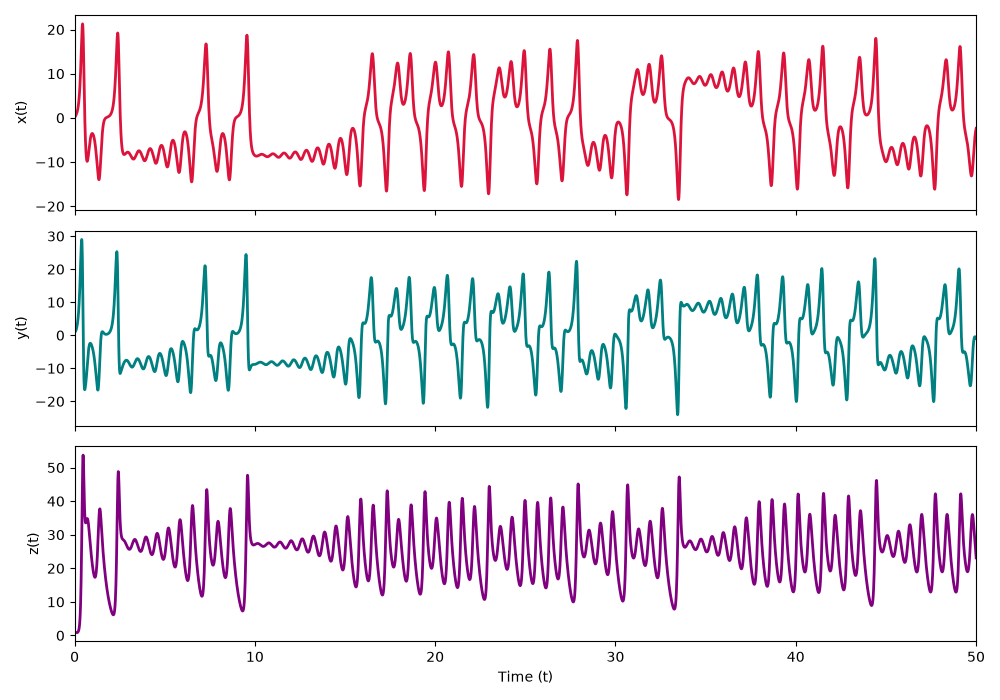

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.linalg import svd
%matplotlib widget

def lorentz (xyz, s=10, r=28, b=2.667) :

    """
    Parameter
    ---------
    xyz : array, shape (3,)

    s,r,b : float
    Lorentz attarractor's parameter 
    """
    x,y,z = xyz
    x_dot = s*(y-x)
    y_dot = r*x - y -x*z
    z_dot = x*y - b*z

    return np.array([x_dot, y_dot, z_dot])

def plot_lorentz ():
    dt = 0.01
    num_steps = 10000
    xyzs =np.empty((num_steps+1,3))
    xyzs[0] = (0.,1.0,1.05)

    for i in range(num_steps):
        xyzs[i+1] = xyzs[i] + lorentz(xyzs[i]) * dt

    x = xyzs[:,0]
    y = xyzs[:,1]
    z = xyzs[:,2]
    t = np.arange(num_steps + 1) * dt


    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, x, color="crimson", lw=2)
    axes[0].set_ylabel("x(t)")
    # axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, y, color="teal", lw=2)
    axes[1].set_ylabel("y(t)")
    # axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, z, color="purple", lw=2)
    axes[2].set_ylabel("z(t)")
    axes[2].set_xlabel("Time (t)")
    # axes[2].grid(True, alpha=0.3)

    plt.xlim(0, 50)
    plt.tight_layout()
    # plt.show()

    return x,y,z,t

x,y,z,timestep = plot_lorentz()

n_delays = 8
n_cols = 5000

first_col = x[:n_delays]
last_row = x[n_delays-1:n_delays-1+n_cols]

H = hankel(first_col, last_row)

print("hankel matrix:", H.shape)

U,s,V = svd(H, full_matrices=False)

plt.figure(figsize=(6, 4))
normalized_s = s / np.sum(s)
plt.plot(
    np.arange(1, len(s) + 1),
    normalized_s,
    "ro",
    markersize=8,
    label=r"$\sigma_k / \sum \sigma$",
)
plt.title("Figure 3: Singular Value Spectrum")
plt.xlabel("Mode Index $k$")
plt.ylabel("Normalized Energy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Shape of U matrix: {U.shape}\n Shape of s matrix: {s.shape} \n Shape of V matrix: {V.shape}")


plt.figure(figsize=(6,4))
plt.plot(V[0,:], V[1,:], lw=2.0)
plt.title("Figure: V Vector 1 and Vector 2")
plt.xlabel("$v_1$")
plt.ylabel("$v_2$")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
plt.plot(timestep[:n_cols], 300*V[1, :], lw=2.0,)
# plt.plot(300*V[2, :], lw=2.0)
# plt.plot(300*V[3, :], lw=2.0)
# plt.plot(300*V[4, :], lw=2.0)
plt.legend(x)
plt.tight_layout()
plt.show()